In [33]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# Añade la carpeta raíz del proyecto al PATH
ROOT_DIR = Path.cwd().parent
#print(f"ROOT_DIR: {ROOT_DIR}")
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

# Import absoluto directo
from src.rl_project.envs.milan_taxy import MilanTaxiEnv
from src.rl_project.models.mdp import MDP, build_model
from src.rl_project.utils.utils import seed_everything, animate_frames, plot_gridworld_values
# from src.rl_project.policies import RandomPolicy, rollout, ValueIterationPolicy, policy_matrices
from src.rl_project.policies import *
from src.rl_project.evaluation import * # solve_policy_direct, iterative_policy_evaluation

seed_everything(42)

env = MilanTaxiEnv()
mdp = MDP()



In [34]:
from src.rl_project.utils.utils import seed_everything, animate_frames
from src.rl_project.policies import RandomPolicy, rollout

seed_everything(42)

env    = MilanTaxiEnv(6,6, max_steps=10, p=0.2)
policy = RandomPolicy(actions_cardinality=env.action_space.n)

frames, _, _, _ = rollout(env, policy)

animate_frames(frames)

In [35]:
nA = mdp.num_actions
nS = mdp.num_states
shape = (6,6)
nS

720

In [36]:
6*6*5*4

720

In [37]:

# P = mdp.P
# R = mdp.R

# assert np.allclose(P.sum(axis=2), 1.0), "each P[s, a, :] must be a probability distribution"
# print("P:", P.shape, " R:", R.shape, " -> all rows sum to 1")

In [38]:
import numpy as np
env.num_states
s = np.ravel_multi_index((0, 0, 2, 0), (6, 6, 5, 4))
for a, name in enumerate(["SOUTH", "NORTH", "EAST", "WEST", "PICKUP", "DROPOFF"]):
    print(f"Action {a} {name} -> {mdp.P[s][a]}")

Action 0 SOUTH -> [(0.8, 128, -1, False), (0.13333333333333333, 8, -1, False), (0.06666666666666667, 28, -1, False)]
Action 1 NORTH -> [(0.8666666666666667, 8, -1, False), (0.06666666666666667, 128, -1, False), (0.06666666666666667, 28, -1, False)]
Action 2 EAST -> [(0.8, 28, -1, False), (0.06666666666666667, 128, -1, False), (0.13333333333333333, 8, -1, False)]
Action 3 WEST -> [(0.8666666666666667, 8, -1, False), (0.06666666666666667, 128, -1, False), (0.06666666666666667, 28, -1, False)]
Action 4 PICKUP -> [(1.0, 8, -10, False)]
Action 5 DROPOFF -> [(1.0, 8, -10, False)]


In [39]:
import numpy as np
P, R = build_model(mdp)

assert np.allclose(P.sum(axis=2), 1.0), "each P[s, a, :] must be a probability distribution"
print("P:", P.shape, " R:", R.shape, " -> all rows sum to 1")

P: (721, 6, 721)  R: (721, 6)  -> all rows sum to 1


In [40]:
GAMMA = 0.99
pi_random = np.ones((nS + 1, nA)) / nA          # uniform random policy

START = env.START
print(START)
START = np.ravel_multi_index((0, 0, 2, 0), (6, 6, 5, 4))
V_random = solve_policy_direct(P, R, pi_random, GAMMA)
print(f"V^random(start) = {V_random[START]:.2f}")

441
V^random(start) = -379.39


In [41]:
V_iter, n_sweeps, deltas = iterative_policy_evaluation(P, R, pi_random, GAMMA)

err = np.max(np.abs(V_iter - V_random))
print(f"{n_sweeps} sweeps  |  max |V_iterative - V_exact| = {err:.2e}")

2191 sweeps  |  max |V_iterative - V_exact| = 8.63e-09


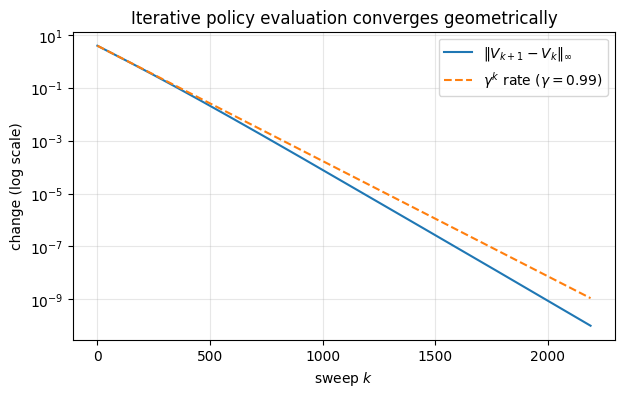

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(deltas, label=r"$\|V_{k+1} - V_k\|_\infty$")
ax.semilogy(deltas[0] * GAMMA ** np.arange(len(deltas)), "--",
            label=rf"$\gamma^k$ rate ($\gamma = {GAMMA}$)")
ax.set_xlabel("sweep $k$")
ax.set_ylabel("change (log scale)")
ax.set_title("Iterative policy evaluation converges geometrically")
ax.legend()
ax.grid(alpha=.3)
plt.show()

In [43]:
V_star_pi, pi_star, n_iters = policy_iteration(P, R, GAMMA)
print(f"converged in {n_iters} iterations  |  V*(start) = {V_star_pi[START]:.2f}")

converged in 1000 iterations  |  V*(start) = 6.06


In [44]:
V_star_vi, pi_vi, n_sweeps_vi, deltas_vi = value_iteration(P, R, GAMMA)

print(f"value iteration:  {n_sweeps_vi} sweeps")
print(f"policy iteration: {n_iters} iterations")
print(f"max |V_VI - V_PI|   = {np.max(np.abs(V_star_vi - V_star_pi)):.2e}")
print(f"same greedy policy: {np.array_equal(pi_vi.argmax(1), pi_star.argmax(1))}")

value iteration:  88 sweeps
policy iteration: 1000 iterations
max |V_VI - V_PI|   = 2.96e-12
same greedy policy: True


In [45]:
# def policy_matrices(P, R, pi):
#     """Average the dynamics over the policy: returns (P_pi, R_pi)."""
#     # Your code goes here: -------------------------------------
#     P_pi = np.einsum('sa,sat->st', pi, P)
#     R_pi = np.einsum('sa,sa->s', pi, R)
#     return P_pi, R_pi
#     # ----------------------------------------------------------


# def solve_policy_direct(P, R, pi, gamma):
#     """Exact V^pi by solving (I - gamma P^pi) V = R^pi."""
#     P_pi, R_pi = policy_matrices(P, R, pi)
#     # Your code goes here: -------------------------------------
#     I = np.eye(P_pi.shape[0])
#     V_pi = np.linalg.solve(I - gamma * P_pi, R_pi)
#     return V_pi
#     # ----------------------------------------------------------

# GAMMA = 0.99
# pi_random = np.ones((nS + 1, nA)) / nA          # uniform random policy

# START = env.START
# print(START)
# # START = np.ravel_multi_index((0, 0, 2, 0), (6, 6, 5, 4))
# V_random = solve_policy_direct(P, R, pi_random, GAMMA)
# print(f"V^random(start) = {V_random[START]:.2f}")

In [46]:
# def iterative_policy_evaluation(P, R, pi, gamma, tol=1e-10, max_iter=100_000):
#     P_pi, R_pi = policy_matrices(P, R, pi)
#     V = np.zeros(P.shape[0])
#     deltas = []

#     for k in range(max_iter):
#         # Your code goes here: -------------------------------------
#         V_new = R_pi + gamma * P_pi @ V
#         delta = np.max(np.abs(V_new - V))
#         deltas.append(delta)
#         V = V_new
#         if delta < tol:
#             break
#         # ----------------------------------------------------------

#     return V, k + 1, deltas


# V_iter, n_sweeps, deltas = iterative_policy_evaluation(P, R, pi_random, GAMMA)

# err = np.max(np.abs(V_iter - V_random))
# print(f"{n_sweeps} sweeps  |  max |V_iterative - V_exact| = {err:.2e}")

In [47]:
# fig, ax = plt.subplots(figsize=(7, 4))
# ax.semilogy(deltas, label=r"$\|V_{k+1} - V_k\|_\infty$")
# ax.semilogy(deltas[0] * GAMMA ** np.arange(len(deltas)), "--",
#             label=rf"$\gamma^k$ rate ($\gamma = {GAMMA}$)")
# ax.set_xlabel("sweep $k$")
# ax.set_ylabel("change (log scale)")
# ax.set_title("Iterative policy evaluation converges geometrically")
# ax.legend()
# ax.grid(alpha=.3)
# plt.show()

In [48]:
# def q_from_v(P, R, V, gamma):
#     """One-step lookahead: Q[s, a] from V."""
#     # Your code goes here: -------------------------------------
#     Q = R + gamma * P @ V
#     return Q
#     # ----------------------------------------------------------


# def greedy_policy(Q):
#     """Deterministic greedy policy, as a one-hot matrix."""
#     # Your code goes here: -------------------------------------
#     pi = np.zeros_like(Q)
#     best_actions = np.argmax(Q, axis=1)
#     pi[np.arange(Q.shape[0]), best_actions] = 1.0
#     return pi
#     # ----------------------------------------------------------


# def policy_iteration(P, R, gamma, max_iter=1_000):
#     pi = np.ones(R.shape) / R.shape[1]      # start from the random policy

#     for k in range(max_iter):
#         # Your code goes here: -------------------------------------
#         V = iterative_policy_evaluation(P, R, pi, gamma)[0]
#         pi = greedy_policy(q_from_v(P, R, V, gamma))   
#         # ----------------------------------------------------------

#     return V, pi, k + 1


# V_star_pi, pi_star, n_iters = policy_iteration(P, R, GAMMA)
# print(f"converged in {n_iters} iterations  |  V*(start) = {V_star_pi[START]:.2f}")

In [49]:
# plot_gridworld_values(
#     V_star_pi[:nS].reshape(shape),
#     title="Optimal value function $V^*$ (policy iteration)",
#     cbar_label="$V^*(s)$",
# )

In [50]:
# def value_iteration(P, R, gamma, tol=1e-10, max_iter=100_000):
#     V = np.zeros(R.shape[0])
#     deltas = []

#     for k in range(max_iter):
#         # Your code goes here: -------------------------------------
#         V_new = np.max(q_from_v(P, R, V, gamma), axis=1)
#         delta = np.max(np.abs(V_new - V))
#         deltas.append(delta)
#         V = V_new
#         if delta < tol:
#             break
#         # ----------------------------------------------------------

#     pi = greedy_policy(q_from_v(P, R, V, gamma))
#     return V, pi, k + 1, deltas


# V_star_vi, pi_vi, n_sweeps_vi, deltas_vi = value_iteration(P, R, GAMMA)

# print(f"value iteration:  {n_sweeps_vi} sweeps")
# print(f"policy iteration: {n_iters} iterations")
# print(f"max |V_VI - V_PI|   = {np.max(np.abs(V_star_vi - V_star_pi)):.2e}")
# print(f"same greedy policy: {np.array_equal(pi_vi.argmax(1), pi_star.argmax(1))}")

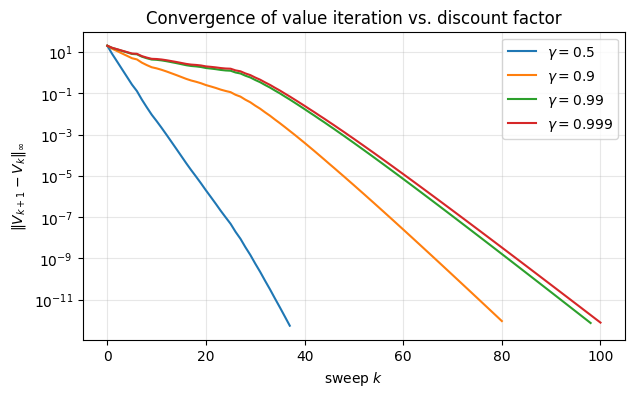

In [51]:
fig, ax = plt.subplots(figsize=(7, 4))

for g in [0.5, 0.9, 0.99, 0.999]:
    _, _, _, d = value_iteration(P, R, g, tol=1e-12)
    ax.semilogy(d, label=rf"$\gamma = {g}$")

ax.set_xlabel("sweep $k$")
ax.set_ylabel(r"$\|V_{k+1} - V_k\|_\infty$")
ax.set_title("Convergence of value iteration vs. discount factor")
ax.legend()
ax.grid(alpha=.3)
plt.show()

In [52]:
seed_everything(42)

policy = ValueIterationPolicy(policy=pi_vi, env=env)

frames, _, _, _ = rollout(env, policy)

animate_frames(frames)

In [53]:
# import sys
# import timeit

# list = [1, 2, 3, 4, 5]
# tuple = (1, 2, 3, 4, 5)

# print(sys.getsizeof(list))  # Tamaño en bytes de la lista
# print(sys.getsizeof(tuple))  # Tamaño en bytes de la tupla

# print("List:  ",timeit.timeit(lambda: list[2], number=1000000))  # Tiempo para crear una list
# print("Tuple: ",timeit.timeit(lambda: tuple[2], number=1000000))  # Tiempo para crear una tupla


In [54]:
# ============================================================
# RESUMEN DE RESULTADOS OBTENIDOS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    "Método": [
        "Random Policy",
        "Policy Iteration",
        "Value Iteration"
    ],

    "V*(start)": [
        V_random[START],
        V_star_pi[START],
        V_star_vi[START]
    ],

    "Iteraciones / sweeps": [
        np.nan,
        n_iters,
        n_sweeps_vi
    ]
})

display(summary.round(4))

,Método,V*(start),Iteraciones / sweeps
0,Random Policy,-379.3870,NaN
1,Policy Iteration,6.0559,1000.0
2,Value Iteration,6.0559,88.0


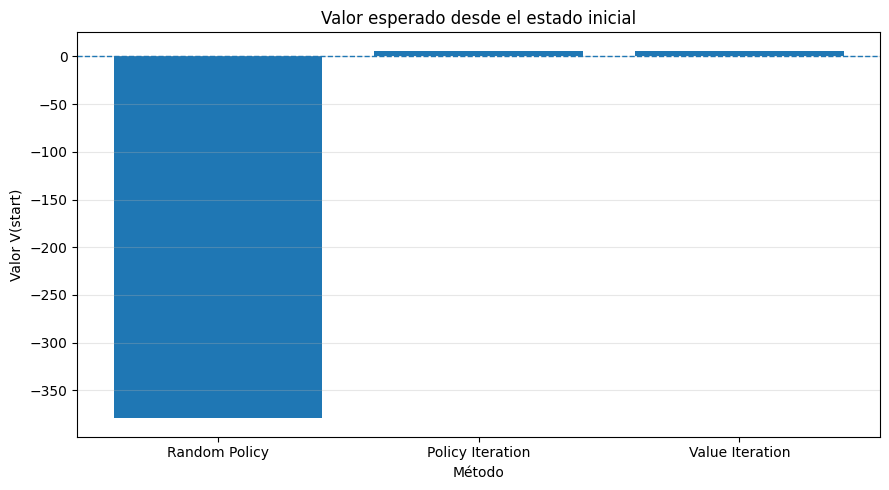

In [55]:
# ============================================================
# COMPARACIÓN DE V(start)
# ============================================================

values = [
    V_random[START],
    V_star_pi[START],
    V_star_vi[START]
]

labels = [
    "Random Policy",
    "Policy Iteration",
    "Value Iteration"
]

plt.figure(figsize=(9, 5))

plt.bar(labels, values)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.ylabel("Valor V(start)")
plt.xlabel("Método")

plt.title(
    "Valor esperado desde el estado inicial"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# DIFERENCIA RESPECTO A RANDOM POLICY
# ============================================================

random_value = V_random[START]

improvement_pi = V_star_pi[START] - random_value
improvement_vi = V_star_vi[START] - random_value

comparison_random = pd.DataFrame({
    "Método": [
        "Policy Iteration",
        "Value Iteration"
    ],

    "V(start)": [
        V_star_pi[START],
        V_star_vi[START]
    ],

    "Diferencia respecto a Random": [
        improvement_pi,
        improvement_vi
    ]
})

display(comparison_random.round(4))

,Método,V(start),Diferencia respecto a Random
0,Policy Iteration,6.0559,385.4429
1,Value Iteration,6.0559,385.4429


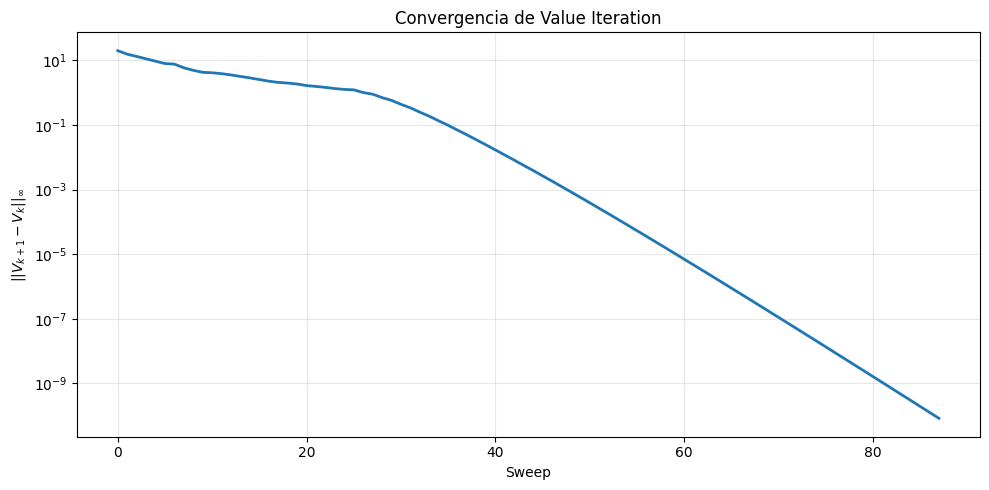

In [57]:
# ============================================================
# CONVERGENCIA DE VALUE ITERATION
# ============================================================

plt.figure(figsize=(10, 5))

plt.semilogy(
    deltas_vi,
    linewidth=2
)

plt.xlabel("Sweep")
plt.ylabel(r"$||V_{k+1} - V_k||_\infty$")

plt.title(
    "Convergencia de Value Iteration"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
# ============================================================
# COMPARACIÓN DE LOS RESULTADOS DE LOS DOS MÉTODOS
# ============================================================

difference = np.max(
    np.abs(V_star_vi - V_star_pi)
)

policy_equal = np.array_equal(
    pi_vi.argmax(axis=1),
    pi_star.argmax(axis=1)
)

results_comparison = pd.DataFrame({
    "Indicador": [
        "V(start) Policy Iteration",
        "V(start) Value Iteration",
        "Máxima diferencia entre V",
        "Iteraciones Policy Iteration",
        "Sweeps Value Iteration",
        "Políticas finales iguales"
    ],

    "Resultado": [
        V_star_pi[START],
        V_star_vi[START],
        difference,
        n_iters,
        n_sweeps_vi,
        policy_equal
    ]
})

display(results_comparison)

,Indicador,Resultado
0,V(start) Policy Iteration,6.055908
1,V(start) Value Iteration,6.055908
2,Máxima diferencia entre V,0.0
3,Iteraciones Policy Iteration,1000
4,Sweeps Value Iteration,88
5,Políticas finales iguales,True


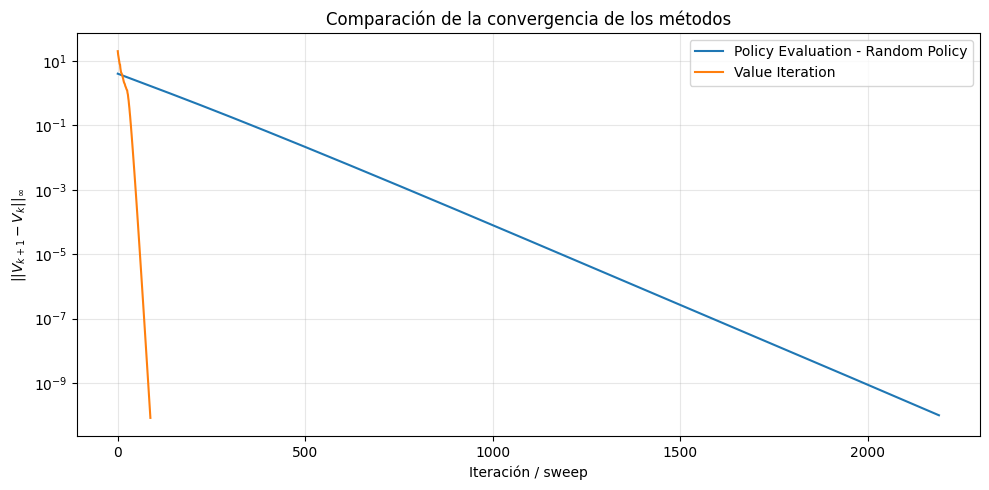

In [59]:
# ============================================================
# CONVERGENCIA DE LOS MÉTODOS
# ============================================================

plt.figure(figsize=(10, 5))

plt.semilogy(
    deltas,
    label="Policy Evaluation - Random Policy"
)

plt.semilogy(
    deltas_vi,
    label="Value Iteration"
)

plt.xlabel("Iteración / sweep")
plt.ylabel(r"$||V_{k+1} - V_k||_\infty$")

plt.title(
    "Comparación de la convergencia de los métodos"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# COMPROBAR DATOS DISPONIBLES DE LAS EJECUCIONES
# ============================================================

print("¿Existe 'rewards'? :", "rewards" in globals())
print("¿Existe 'frames'?  :", "frames" in globals())

if "frames" in globals():
    print("Número de frames disponibles:", len(frames))

¿Existe 'rewards'? : False
¿Existe 'frames'?  : True
Número de frames disponibles: 10


In [61]:
# ============================================================
# RECUPERAR LAS DOS EJECUCIONES GUARDANDO LOS REWARDS
# ============================================================

# RANDOM POLICY
seed_everything(42)

random_policy = RandomPolicy(
    actions_cardinality=env.action_space.n
)

random_frames, random_states, random_actions, random_rewards = rollout(
    env,
    random_policy
)


# VALUE ITERATION
seed_everything(42)

vi_policy = ValueIterationPolicy(
    policy=pi_vi,
    env=env
)

vi_frames, vi_states, vi_actions, vi_rewards = rollout(
    env,
    vi_policy
)


print("Random Policy:")
print("  pasos  :", len(random_rewards))
print("  reward :", np.sum(random_rewards))

print("\nValue Iteration:")
print("  pasos  :", len(vi_rewards))
print("  reward :", np.sum(vi_rewards))

Random Policy:
  pasos  : 10
  reward : -64

Value Iteration:
  pasos  : 10
  reward : -10


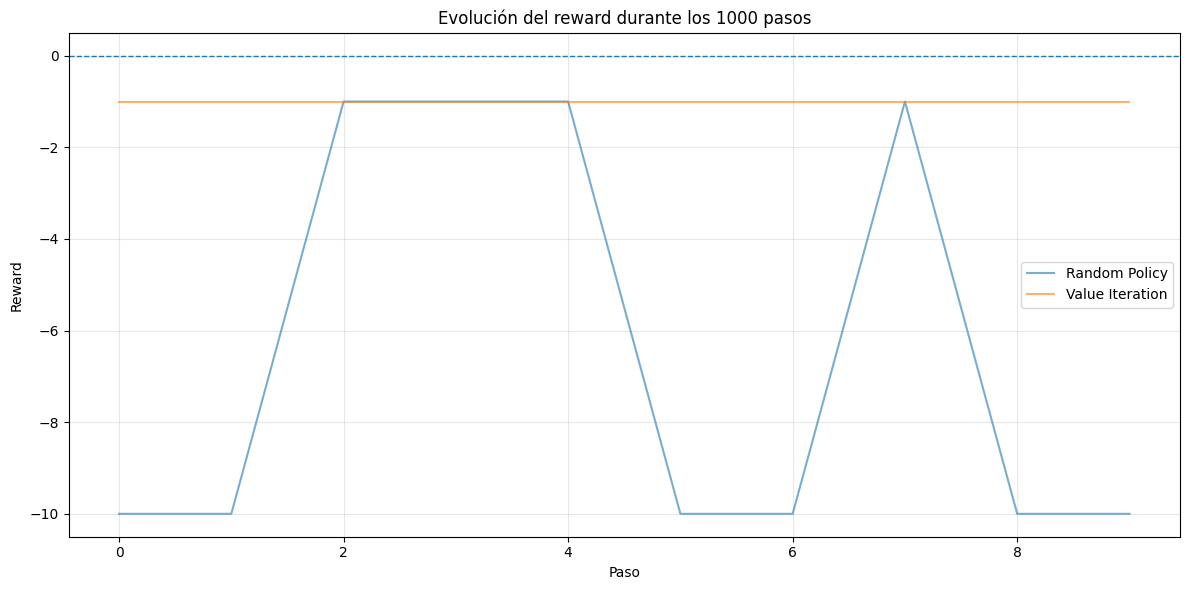

In [62]:
# ============================================================
# REWARD EN CADA PASO
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    random_rewards,
    alpha=0.6,
    label="Random Policy"
)

plt.plot(
    vi_rewards,
    alpha=0.6,
    label="Value Iteration"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Paso")
plt.ylabel("Reward")

plt.title(
    "Evolución del reward durante los 1000 pasos"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

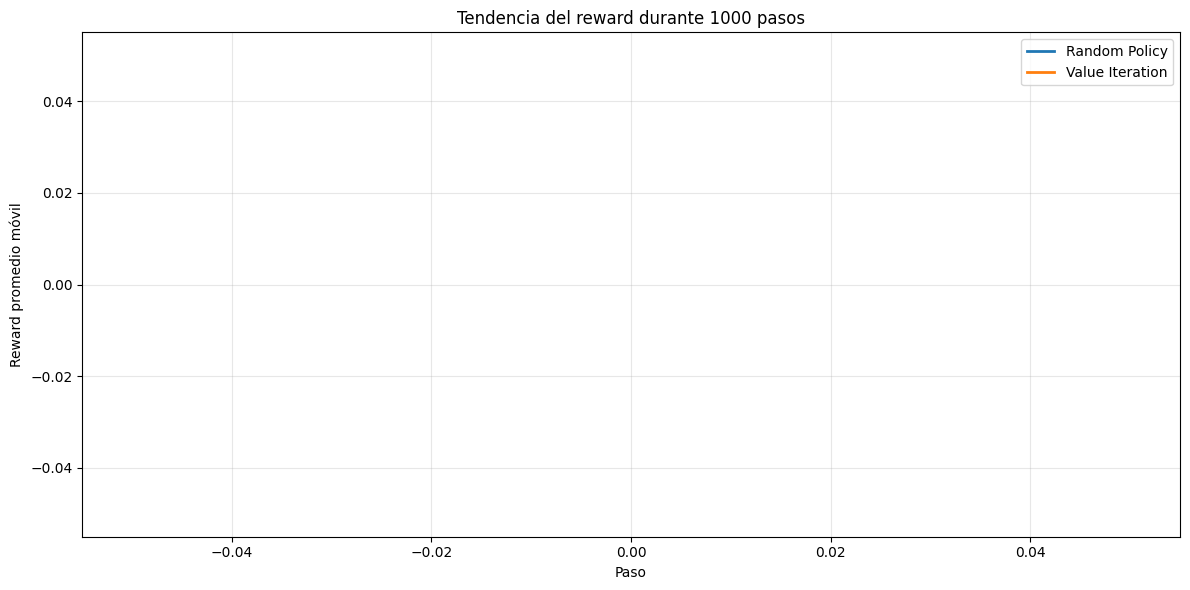

In [63]:
# ============================================================
# TENDENCIA DEL REWARD - MEDIA MÓVIL
# ============================================================

window = 50

random_trend = pd.Series(
    random_rewards
).rolling(window).mean()

vi_trend = pd.Series(
    vi_rewards
).rolling(window).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    random_trend,
    linewidth=2,
    label="Random Policy"
)

plt.plot(
    vi_trend,
    linewidth=2,
    label="Value Iteration"
)

plt.xlabel("Paso")
plt.ylabel("Reward promedio móvil")

plt.title(
    "Tendencia del reward durante 1000 pasos"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ESTADÍSTICAS DE LOS 1000 PASOS
# ============================================================

results_table = pd.DataFrame({
    "Métrica": [
        "Pasos",
        "Reward total",
        "Reward promedio",
        "Reward mediano",
        "Desviación estándar",
        "Reward máximo",
        "Reward mínimo"
    ],

    "Random Policy": [
        len(random_rewards),
        np.sum(random_rewards),
        np.mean(random_rewards),
        np.median(random_rewards),
        np.std(random_rewards),
        np.max(random_rewards),
        np.min(random_rewards)
    ],

    "Value Iteration": [
        len(vi_rewards),
        np.sum(vi_rewards),
        np.mean(vi_rewards),
        np.median(vi_rewards),
        np.std(vi_rewards),
        np.max(vi_rewards),
        np.min(vi_rewards)
    ]
})

display(results_table.round(3))